# Spectral content and ~10 Hz transient artifact

Same session and tetrode selection as `debug.ipynb`. For each of the three
recordings in the session we:

1. Compute per-channel power spectral densities with 1 s Welch windows and
   plot the per-channel PSDs along with the channel-mean PSD.
2. Pull prominent peaks out of the mean PSD and group them into harmonic
   series.
3. Detect the sharp transient that recurs at ~10 Hz and look for
   sample-precise periodicity in its inter-event intervals.
4. Look at whether the artifact has any structure related to Open Ephys
   hardware-channel index (e.g. striping every k channels).

Recording 0 is analyzed in depth; recordings 1 and 2 reuse the same
helpers for comparison.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from scipy import signal as sp_signal

from tetrode_analyses import load_tetrode_dataarray, print_session_tree

In [2]:
ACQ_DIR = Path("/Volumes/neuropixel_archive/tetrode_data/2026-05-19_18-09-51")
SELECTED_TETRODES = [1, 3, 6, 14, 15, 16]
STREAM_INDEX = 0  # acquisition_board

print_session_tree(ACQ_DIR)

Session: /Volumes/neuropixel_archive/tetrode_data/2026-05-19_18-09-51
  Record Node 101 (binary)  [record_node_index=0]
    Experiment 0
      Recording 0  [recording_index=0]
        Stream 0: acquisition_board  — 64 ch, 1,815,085 samples @ 30000.0 Hz, 60.503 s
        Stream 1: memory_usage  — 1 ch, 6,050 samples @ 100.0 Hz, 60.500 s
      Recording 1  [recording_index=1]
        Stream 0: acquisition_board  — 64 ch, 1,807,473 samples @ 30000.0 Hz, 60.249 s
        Stream 1: memory_usage  — 1 ch, 6,025 samples @ 100.0 Hz, 60.250 s
      Recording 2  [recording_index=2]
        Stream 0: acquisition_board  — 64 ch, 1,788,934 samples @ 30000.0 Hz, 59.631 s
        Stream 1: memory_usage  — 1 ch, 5,963 samples @ 100.0 Hz, 59.630 s


## Helpers

Factored so the same pipeline runs on every recording.

In [3]:
def channel_psds(samples: np.ndarray, fs: float, nperseg: int | None = None):
    """Welch PSD per channel.

    ``samples`` is ``(n_samples, n_channels)``. Returns ``(freqs, psds)``
    where ``psds`` has shape ``(n_freqs, n_channels)``.
    """
    if nperseg is None:
        nperseg = int(round(fs))  # 1 s windows
    freqs, psds = sp_signal.welch(samples, fs=fs, nperseg=nperseg, axis=0)
    return freqs, psds


def detect_transients(
    x: np.ndarray,
    fs: float,
    hp_cutoff: float = 300.0,
    threshold_mad: float = 6.0,
    min_distance_s: float = 0.05,
):
    """High-pass + robust threshold detector for sharp transients.

    Returns peak sample indices, the high-passed signal, and the
    absolute-amplitude threshold actually used.
    """
    sos = sp_signal.butter(4, hp_cutoff, btype="high", fs=fs, output="sos")
    hp = sp_signal.sosfiltfilt(sos, x)
    abs_hp = np.abs(hp)
    med = np.median(abs_hp)
    mad = np.median(np.abs(abs_hp - med))
    threshold = med + threshold_mad * 1.4826 * mad
    distance = max(1, int(round(min_distance_s * fs)))
    peaks, _ = sp_signal.find_peaks(abs_hp, height=threshold, distance=distance)
    return peaks, hp, threshold


def find_psd_peaks(
    freqs: np.ndarray,
    psd: np.ndarray,
    fmin: float = 1.0,
    fmax: float | None = None,
    prominence_db: float = 6.0,
    min_distance_hz: float = 0.5,
):
    """Find peaks in dB PSD between ``fmin`` and ``fmax``."""
    if fmax is None:
        fmax = freqs[-1]
    mask = (freqs >= fmin) & (freqs <= fmax)
    f = freqs[mask]
    p_db = 10 * np.log10(psd[mask] + 1e-30)
    df = f[1] - f[0]
    distance = max(1, int(round(min_distance_hz / df)))
    idx, props = sp_signal.find_peaks(p_db, prominence=prominence_db, distance=distance)
    return f[idx], p_db[idx], props["prominences"]


def harmonic_groups(peak_freqs: np.ndarray, tolerance: float = 0.05):
    """Group peaks by best-fitting fundamental.

    Each peak is assigned to whichever existing fundamental f0 makes
    ``peak/round(peak/f0) ≈ f0`` within ``tolerance`` (relative). If none
    fits, the peak becomes a new fundamental at the lowest order it can.
    Returns ``dict[f0 -> list[(order, freq)]]``.
    """
    peak_freqs = np.sort(np.asarray(peak_freqs, dtype=float))
    groups: dict[float, list[tuple[int, float]]] = {}
    for f in peak_freqs:
        assigned = False
        for f0 in list(groups):
            order = int(round(f / f0))
            if order >= 1 and abs(f - order * f0) / (order * f0) <= tolerance:
                groups[f0].append((order, f))
                assigned = True
                break
        if not assigned:
            groups[f] = [(1, f)]
    return groups

## 1. Recording 0: per-channel PSDs (1 s windows)

Load the 24 selected tetrode channels and run Welch PSD with `nperseg = fs`
(1 s windows, default 50% overlap).

In [4]:
da0 = load_tetrode_dataarray(
    ACQ_DIR,
    recording_index=0,
    stream_index=STREAM_INDEX,
    selected_tetrodes=SELECTED_TETRODES,
    layout="2d_flat_index",
)
fs = float(da0.attrs["fs"])
print(da0)

<xarray.DataArray (time: 1815085, channel: 24)> Size: 348MB
array([[ 65.71499757,  62.98499767,  61.61999772, ..., 147.80999454,
        158.33999415, 157.75499418],
       [ 54.59999798,  58.30499785,  56.35499792, ..., 143.90999469,
        150.53999444, 146.2499946 ],
       [ 42.11999844,  54.40499799,  44.65499835, ..., 148.58999451,
        165.55499389, 164.18999394],
       ...,
       [-49.33499818, -42.31499844, -60.05999778, ...,  -9.94499963,
          3.11999988,   8.96999967],
       [-43.67999839, -30.22499888, -45.23999833, ...,   8.1899997 ,
         10.9199996 ,  26.71499901],
       [-29.05499893, -42.70499842, -48.55499821, ...,   9.16499966,
          7.40999973,  23.98499911]], shape=(1815085, 24))
Coordinates:
  * time      (time) float64 15MB 18.67 18.67 18.67 18.67 ... 79.17 79.17 79.17
  * channel   (channel) int64 192B 1 2 3 4 9 10 11 12 ... 58 59 60 61 62 63 64
    tetrode   (channel) int64 192B 1 1 1 1 3 3 3 3 6 ... 15 15 15 15 16 16 16 16
    oe_index  (ch

In [5]:
freqs0, psds0 = channel_psds(da0.values, fs=fs)
mean_psd0 = psds0.mean(axis=1)
print(f"freqs: {freqs0[0]:.3f} .. {freqs0[-1]:.1f} Hz, df = {freqs0[1] - freqs0[0]:.3f} Hz")
print(f"psds shape: {psds0.shape}")

freqs: 0.000 .. 15000.0 Hz, df = 1.000 Hz
psds shape: (15001, 24)


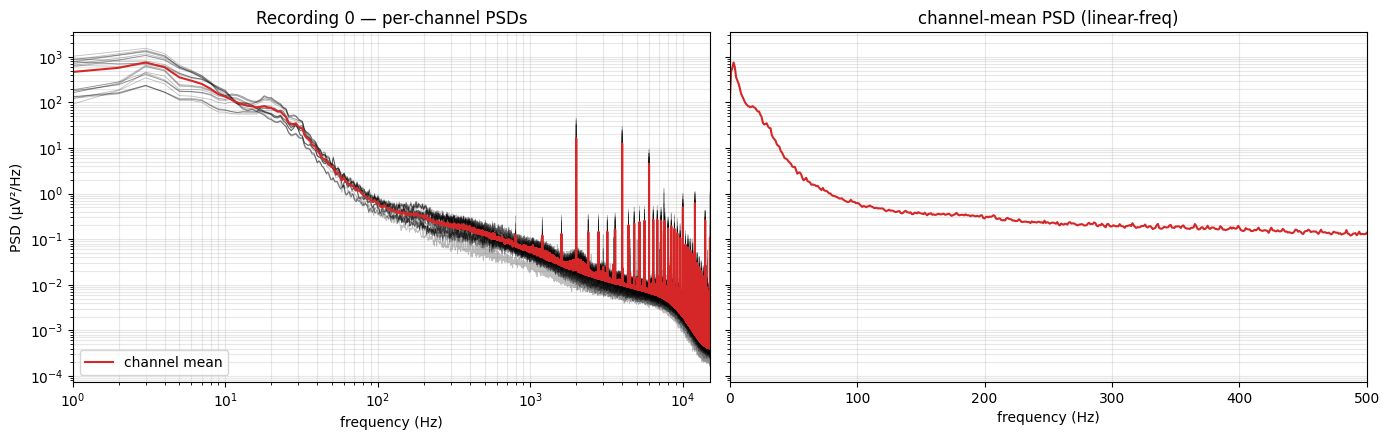

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), sharey=True)

for i in range(psds0.shape[1]):
    axes[0].loglog(freqs0, psds0[:, i], color="k", alpha=0.25, lw=0.6)
axes[0].loglog(freqs0, mean_psd0, color="C3", lw=1.5, label="channel mean")
axes[0].set(xlabel="frequency (Hz)", ylabel="PSD (\u00b5V\u00b2/Hz)",
            title="Recording 0 \u2014 per-channel PSDs")
axes[0].set_xlim(freqs0[1], freqs0[-1])
axes[0].legend(loc="lower left")
axes[0].grid(True, which="both", alpha=0.3)

axes[1].semilogy(freqs0, mean_psd0, color="C3")
axes[1].set(xlabel="frequency (Hz)", title="channel-mean PSD (linear-freq)")
axes[1].set_xlim(0, 500)
axes[1].grid(True, which="both", alpha=0.3)

fig.tight_layout()
plt.show()

## 2. PSD peaks and harmonics

Look for line-noise harmonics and any narrowband sources between 1 Hz
and the Nyquist frequency. We group peaks by best-fitting fundamental
so 60/120/180 Hz collapse into one row.

In [7]:
peak_f, peak_db, peak_prom = find_psd_peaks(freqs0, mean_psd0, fmin=1.0)
groups = harmonic_groups(peak_f)

print(f"Detected {len(peak_f)} prominent peaks in mean PSD (\u2265 6 dB prominence)")
print("\nHarmonic groupings (fundamental \u2192 [(order, freq Hz)...]):")
for f0 in sorted(groups):
    series = groups[f0]
    if len(series) == 1:
        print(f"  isolated  {f0:8.3f} Hz")
    else:
        labels = ", ".join(f"{o}x={fi:.2f}" for o, fi in series)
        print(f"  f0 = {f0:7.3f} Hz: {labels}")

Detected 46 prominent peaks in mean PSD (≥ 6 dB prominence)

Harmonic groupings (fundamental → [(order, freq Hz)...]):
  f0 = 1596.000 Hz: 1x=1596.00, 2x=3192.00, 3x=4789.00, 4x=6385.00, 5x=7582.00, 5x=7981.00, 5x=8052.00, 6x=9178.00, 6x=9577.00, 6x=9977.00, 6x=10047.00, 7x=10775.00, 7x=11000.00, 7x=11174.00, 7x=11500.00, 7x=11573.00, 8x=12371.00, 8x=12770.00, 8x=13169.00, 9x=13967.00, 9x=14038.00, 9x=14366.00, 9x=14437.00, 9x=14500.00, 9x=14765.00, 9x=14836.00
  f0 = 1995.000 Hz: 1x=1995.00, 2x=3991.00, 3x=5986.00, 5x=10376.00, 6x=11972.00, 6x=12000.00, 6x=12042.00, 7x=13568.00, 7x=13638.00
  f0 = 2394.000 Hz: 1x=2394.00, 3x=7183.00, 3x=7500.00
  f0 = 2793.000 Hz: 1x=2793.00, 2x=5587.00, 3x=8380.00, 3x=8779.00
  isolated  3592.000 Hz
  isolated  4390.000 Hz
  isolated  5188.000 Hz
  isolated  6784.000 Hz


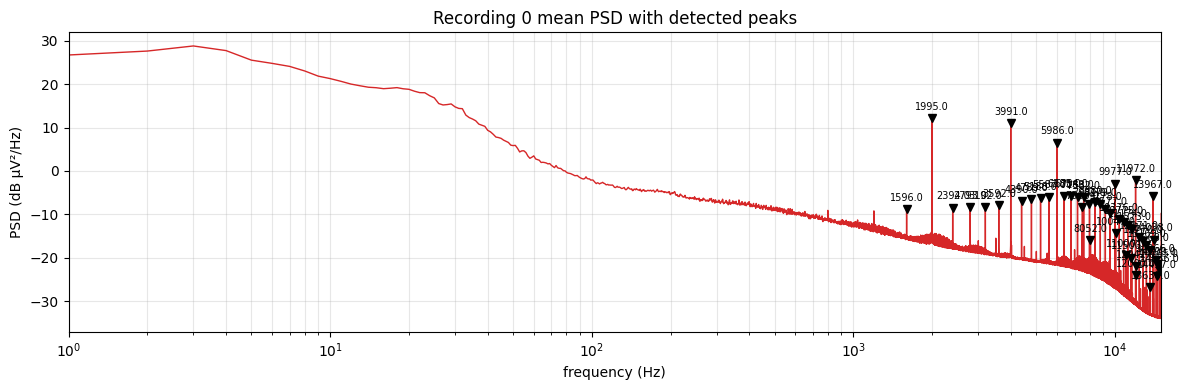

In [8]:
fig, ax = plt.subplots(figsize=(12, 4))
p_db_full = 10 * np.log10(mean_psd0 + 1e-30)
ax.plot(freqs0, p_db_full, color="C3", lw=1)
ax.plot(peak_f, peak_db, "v", color="k", ms=6)
for f, db in zip(peak_f, peak_db):
    ax.annotate(f"{f:.1f}", (f, db), xytext=(0, 6), textcoords="offset points",
                ha="center", fontsize=7)
ax.set(xlabel="frequency (Hz)", ylabel="PSD (dB \u00b5V\u00b2/Hz)",
       title="Recording 0 mean PSD with detected peaks")
ax.set_xscale("log")
ax.set_xlim(freqs0[1], freqs0[-1])
ax.grid(True, which="both", alpha=0.3)
fig.tight_layout()
plt.show()

## 2b. Are the spectral peaks the same on every channel?

Run the peak detector on each channel's PSD individually (rather than on
the mean) and ask: how many channels does each candidate peak appear on?
Peaks that show up on *all* channels with the same Hz value are almost
certainly common-mode and consistent with a clocked acquisition source.

In [9]:
per_channel_peaks = []
for c in range(psds0.shape[1]):
    pf, _, _ = find_psd_peaks(freqs0, psds0[:, c], fmin=1.0, prominence_db=6.0)
    per_channel_peaks.append(np.round(pf).astype(int))

# Pool candidate peak frequencies and count channel co-occurrence (rounded to 1 Hz).
from collections import Counter
pool = Counter()
for pf in per_channel_peaks:
    pool.update(pf.tolist())

n_ch = psds0.shape[1]
candidates = sorted(f for f, c in pool.items() if c >= max(2, n_ch // 4))
present = np.zeros((n_ch, len(candidates)), dtype=bool)
for c, pf in enumerate(per_channel_peaks):
    s = set(pf.tolist())
    for j, f in enumerate(candidates):
        # Accept ±1 Hz tolerance (1 Hz bin width)
        present[c, j] = bool(s & {f - 1, f, f + 1})

per_chan_count = present.sum(axis=0)
universal = [candidates[j] for j in range(len(candidates)) if per_chan_count[j] == n_ch]
print(f"{len(universal)} peaks appear on ALL {n_ch} channels:")
for f in universal:
    print(f"  {f} Hz")
print()

high_agreement = [(candidates[j], per_chan_count[j]) for j in range(len(candidates))
                  if per_chan_count[j] >= n_ch - 2 and candidates[j] not in universal]
print(f"Peaks on \u2265 {n_ch - 2}/{n_ch} channels (near-universal):")
for f, n in sorted(high_agreement):
    print(f"  {f} Hz: {n}/{n_ch}")

37 peaks appear on ALL 24 channels:
  1995 Hz
  3192 Hz
  3592 Hz
  3991 Hz
  4390 Hz
  4789 Hz
  5188 Hz
  5587 Hz
  5986 Hz
  6385 Hz
  6784 Hz
  7183 Hz
  7582 Hz
  7981 Hz
  8052 Hz
  8380 Hz
  8779 Hz
  9178 Hz
  9577 Hz
  9977 Hz
  10047 Hz
  10376 Hz
  10775 Hz
  11174 Hz
  11573 Hz
  11972 Hz
  12042 Hz
  12371 Hz
  12770 Hz
  13169 Hz
  13568 Hz
  13967 Hz
  14038 Hz
  14366 Hz
  14437 Hz
  14765 Hz
  14836 Hz

Peaks on ≥ 22/24 channels (near-universal):
  2793 Hz: 23/24


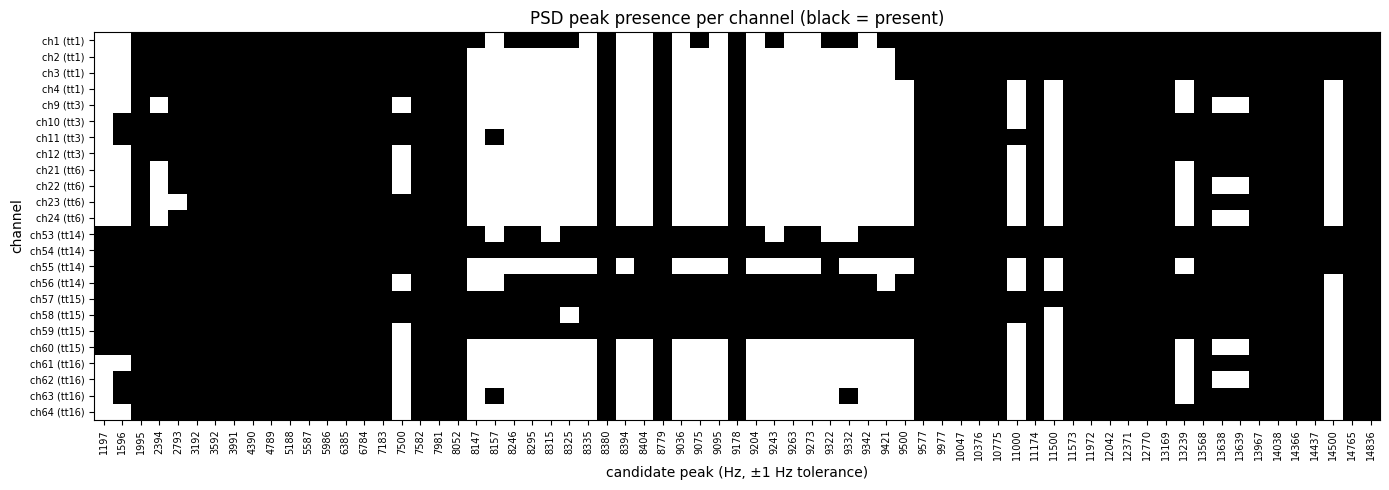

In [10]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.imshow(present.astype(int), aspect="auto", cmap="Greys", interpolation="nearest",
          extent=[-0.5, len(candidates) - 0.5, n_ch - 0.5, -0.5])
ax.set_xticks(range(len(candidates)))
ax.set_xticklabels([str(f) for f in candidates], rotation=90, fontsize=7)
ax.set_yticks(range(n_ch))
ax.set_yticklabels([f"ch{int(c)} (tt{int(t)})" for c, t in
                     zip(da0["channel"].values, da0["tetrode"].values)], fontsize=7)
ax.set(xlabel="candidate peak (Hz, \u00b11 Hz tolerance)",
       ylabel="channel",
       title="PSD peak presence per channel (black = present)")
fig.tight_layout()
plt.show()

## 3. Detect the ~10 Hz sharp transient

High-pass at 300 Hz to isolate the transient from low-frequency LFP and
60 Hz harmonics, then threshold on robust (MAD) baseline.

In [11]:
ch0 = da0.values[:, 0]
peaks0, hp0, thr0 = detect_transients(ch0, fs=fs)
n_events = len(peaks0)
duration = da0.sizes["time"] / fs
print(f"{n_events} events on channel 0 over {duration:.2f} s "
      f"=> {n_events / duration:.3f} Hz")

598 events on channel 0 over 60.50 s => 9.884 Hz


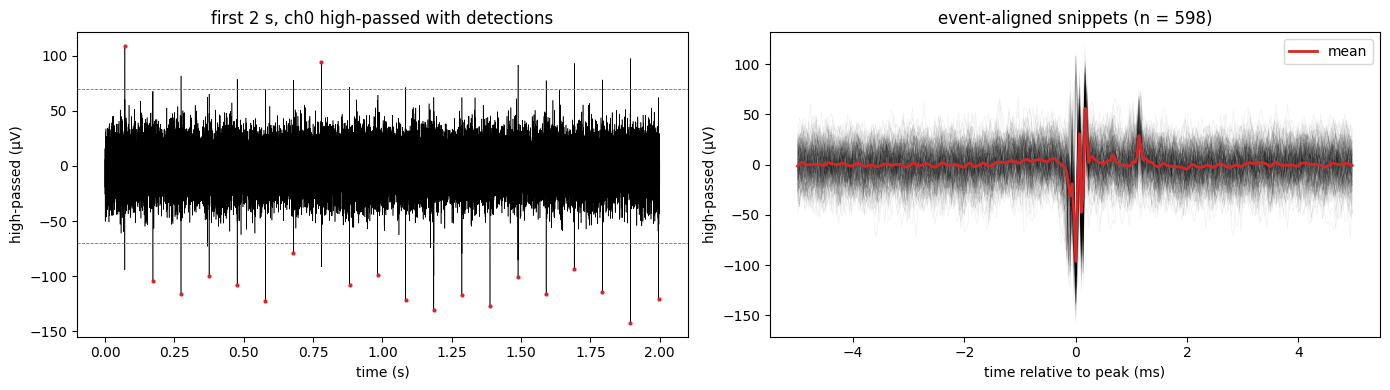

In [12]:
win = int(0.005 * fs)  # \u00b15 ms around peak
snippets = np.stack([hp0[p - win:p + win] for p in peaks0
                     if win <= p < len(hp0) - win])
t_snip = np.arange(-win, win) / fs * 1e3

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

t = np.arange(len(hp0)) / fs
show = slice(0, int(2 * fs))  # first 2 s
axes[0].plot(t[show], hp0[show], lw=0.4, color="k")
axes[0].plot(peaks0[peaks0 < show.stop] / fs,
             hp0[peaks0[peaks0 < show.stop]], ".", color="C3", ms=4)
axes[0].axhline(thr0, color="C2", lw=0.6, ls="--")
axes[0].axhline(-thr0, color="C2", lw=0.6, ls="--")
axes[0].set(xlabel="time (s)", ylabel="high-passed (\u00b5V)",
            title="first 2 s, ch0 high-passed with detections")

for s in snippets[: min(200, len(snippets))]:
    axes[1].plot(t_snip, s, color="k", alpha=0.06, lw=0.5)
axes[1].plot(t_snip, snippets.mean(axis=0), color="C3", lw=2, label="mean")
axes[1].set(xlabel="time relative to peak (ms)", ylabel="high-passed (\u00b5V)",
            title=f"event-aligned snippets (n = {len(snippets)})")
axes[1].legend()

fig.tight_layout()
plt.show()

## 4. Sample-precise periodicity?

Inter-event sample intervals: if the artifact is hardware-clocked the
modal interval should account for nearly every gap, and the spread
should be 0\u20131 samples.

In [13]:
diffs0 = np.diff(peaks0)
vals, counts = np.unique(diffs0, return_counts=True)
order = np.argsort(counts)[::-1]
modal_interval = int(vals[order[0]])
modal_freq = fs / modal_interval
print(f"inter-event intervals: min={diffs0.min()} max={diffs0.max()} "
      f"mean={diffs0.mean():.2f} median={int(np.median(diffs0))}")
print(f"modal interval = {modal_interval} samples "
      f"({modal_interval / fs * 1e3:.4f} ms, {modal_freq:.4f} Hz)")
print("top intervals (samples, count):")
for v, c in zip(vals[order[:10]], counts[order[:10]]):
    print(f"  {int(v):6d}  {int(c):5d}  ({c / diffs0.size * 100:.1f}%)")

exact = np.sum(diffs0 == modal_interval)
within1 = np.sum(np.abs(diffs0 - modal_interval) <= 1)
print(f"\n{exact}/{diffs0.size} ({exact / diffs0.size * 100:.1f}%) intervals "
      f"exactly equal modal value")
print(f"{within1}/{diffs0.size} ({within1 / diffs0.size * 100:.1f}%) within \u00b11 sample")

inter-event intervals: min=1506 max=6075 mean=3032.84 median=3038
modal interval = 3038 samples (101.2667 ms, 9.8749 Hz)
top intervals (samples, count):
    3038    276  (46.2%)
    3037     52  (8.7%)
    3039     44  (7.4%)
    3041     39  (6.5%)
    3034     36  (6.0%)
    3042     28  (4.7%)
    3033     26  (4.4%)
    3035     25  (4.2%)
    3043     24  (4.0%)
    3032      8  (1.3%)

276/597 (46.2%) intervals exactly equal modal value
372/597 (62.3%) within ±1 sample


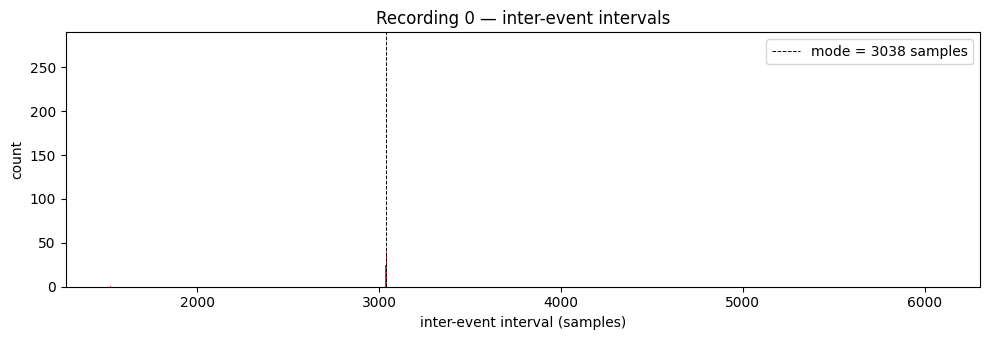

In [14]:
fig, ax = plt.subplots(figsize=(10, 3.5))
bins = np.arange(diffs0.min() - 0.5, diffs0.max() + 1.5)
ax.hist(diffs0, bins=bins, color="C3")
ax.axvline(modal_interval, color="k", lw=0.7, ls="--",
           label=f"mode = {modal_interval} samples")
ax.set(xlabel="inter-event interval (samples)", ylabel="count",
       title="Recording 0 \u2014 inter-event intervals")
ax.legend()
fig.tight_layout()
plt.show()

## 4b. Sign-aware artifact detection

`detect_transients` thresholds on `|hp|`, which means a positive-going
peak and a negative-going peak both register as separate events if they
arrive close together — and the *aligned* timestamps will mix the
positive-lobe time and the negative-lobe time of what may be a single
biphasic transient. Re-run separately for positive and negative excursions
and compare the interval distributions.

In [15]:
# Reuse the same threshold logic as detect_transients but split by sign.
abs_hp = np.abs(hp0)
med = np.median(abs_hp)
mad = np.median(np.abs(abs_hp - med))
thr_signed = med + 6 * 1.4826 * mad
distance = max(1, int(round(0.05 * fs)))

pos_peaks, _ = sp_signal.find_peaks(hp0, height=thr_signed, distance=distance)
neg_peaks, _ = sp_signal.find_peaks(-hp0, height=thr_signed, distance=distance)


def interval_summary(peaks, label):
    if peaks.size < 2:
        print(f"{label}: {peaks.size} events, nothing to summarize")
        return
    diffs = np.diff(peaks)
    vals, counts = np.unique(diffs, return_counts=True)
    order = np.argsort(counts)[::-1]
    mode = int(vals[order[0]])
    exact = int(np.sum(diffs == mode))
    within1 = int(np.sum(np.abs(diffs - mode) <= 1))
    print(f"{label}: n={peaks.size}, modal interval = {mode} samp "
          f"({mode / fs * 1e3:.4f} ms, {fs / mode:.4f} Hz)")
    print(f"  %exact = {exact / diffs.size * 100:.1f}, "
          f"within \u00b11 samp = {within1 / diffs.size * 100:.1f}")
    top = list(zip(vals[order[:5]].astype(int), counts[order[:5]].astype(int)))
    print(f"  top intervals: {top}")


print("Combined |hp| detector (original):")
interval_summary(peaks0, "  |hp|")
print()
print("Sign-split detectors:")
interval_summary(pos_peaks, "  positive")
interval_summary(neg_peaks, "  negative")

Combined |hp| detector (original):
  |hp|: n=598, modal interval = 3038 samp (101.2667 ms, 9.8749 Hz)
  %exact = 46.2, within ±1 samp = 62.3
  top intervals: [(np.int64(3038), np.int64(276)), (np.int64(3037), np.int64(52)), (np.int64(3039), np.int64(44)), (np.int64(3041), np.int64(39)), (np.int64(3034), np.int64(36))]

Sign-split detectors:
  positive: n=367, modal interval = 3038 samp (101.2667 ms, 9.8749 Hz)
  %exact = 44.5, within ±1 samp = 59.8
  top intervals: [(np.int64(3038), np.int64(163)), (np.int64(3037), np.int64(33)), (np.int64(3039), np.int64(23)), (np.int64(6076), np.int64(20)), (np.int64(6075), np.int64(16))]
  negative: n=598, modal interval = 3038 samp (101.2667 ms, 9.8749 Hz)
  %exact = 53.4, within ±1 samp = 71.7
  top intervals: [(np.int64(3038), np.int64(319)), (np.int64(3037), np.int64(62)), (np.int64(3041), np.int64(47)), (np.int64(3039), np.int64(47)), (np.int64(3034), np.int64(39))]


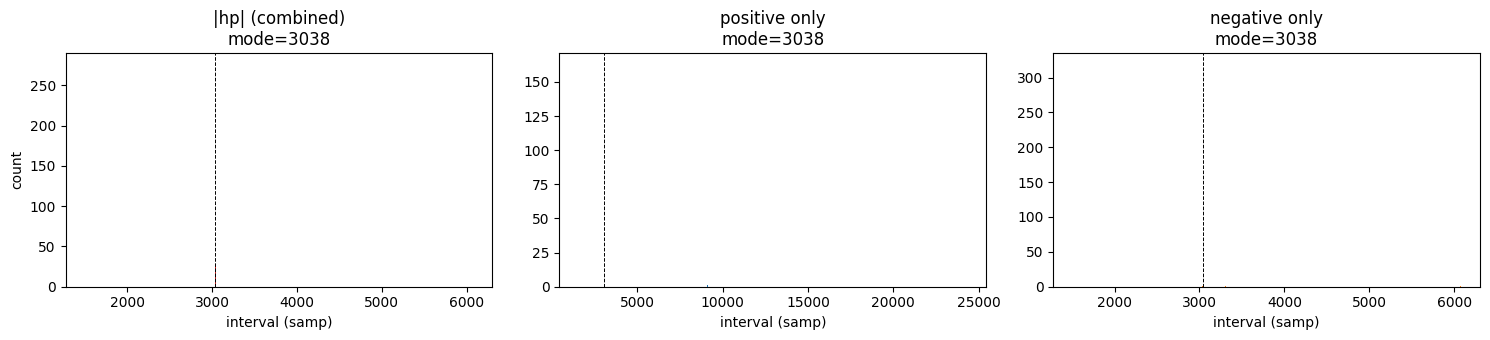

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.5), sharex=False)
for ax, peaks, name, color in zip(
    axes,
    (peaks0, pos_peaks, neg_peaks),
    ("|hp| (combined)", "positive only", "negative only"),
    ("C3", "C0", "C1"),
):
    if peaks.size < 2:
        ax.set_title(f"{name}: <2 events")
        continue
    diffs = np.diff(peaks)
    bins = np.arange(diffs.min() - 0.5, diffs.max() + 1.5)
    ax.hist(diffs, bins=bins, color=color)
    mode = int(np.bincount(diffs).argmax())
    ax.axvline(mode, color="k", lw=0.7, ls="--")
    ax.set(xlabel="interval (samp)", title=f"{name}\nmode={mode}")
axes[0].set_ylabel("count")
fig.tight_layout()
plt.show()

## 5. Spatial pattern across Open Ephys channels

Load **all 16 tetrodes** (64 channels) so we have the full OE-channel
axis to look for striping. Use the events detected on channel 0 of the
selected subset as the alignment reference, then build the
event-triggered average for every OE channel and order rows by OE
index.

In [17]:
da0_all = load_tetrode_dataarray(
    ACQ_DIR,
    recording_index=0,
    stream_index=STREAM_INDEX,
    selected_tetrodes=None,
    layout="2d_flat_index",
)
oe_index = da0_all["oe_index"].values
order_by_oe = np.argsort(oe_index)
data_all = da0_all.values  # (ns, 64)
print("loaded all channels:", data_all.shape, "oe_index range:", oe_index.min(), oe_index.max())

loaded all channels: (1815085, 64) oe_index range: 0 63


In [18]:
sos_hp = sp_signal.butter(4, 300, btype="high", fs=fs, output="sos")
hp_all = sp_signal.sosfiltfilt(sos_hp, data_all, axis=0)

valid = peaks0[(peaks0 >= win) & (peaks0 < hp_all.shape[0] - win)]
snip_idx = valid[:, None] + np.arange(-win, win)[None, :]
eta = hp_all[snip_idx, :].mean(axis=0)  # (2*win, 64) event-triggered average
eta_by_oe = eta[:, order_by_oe]
oe_sorted = oe_index[order_by_oe]

peak_amp = eta_by_oe[np.abs(eta_by_oe).argmax(axis=0), np.arange(eta_by_oe.shape[1])]
amp_at_zero = eta_by_oe[win, :]

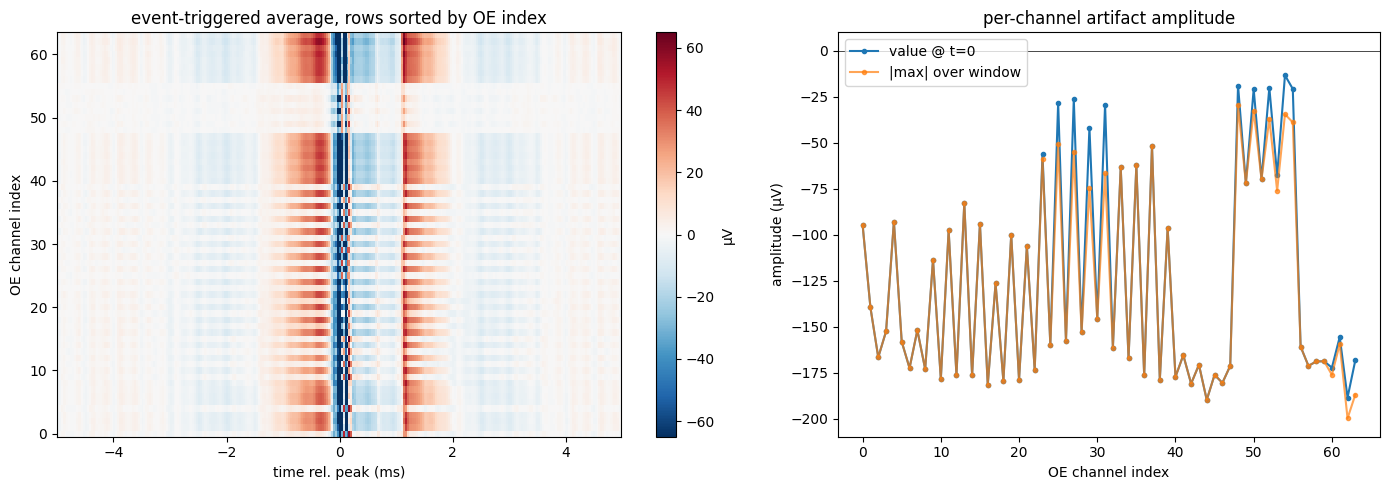

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5),
                          gridspec_kw={"width_ratios": [1.3, 1]})

vmax = np.percentile(np.abs(eta_by_oe), 99)
im = axes[0].imshow(eta_by_oe.T, aspect="auto", origin="lower",
                    extent=[t_snip[0], t_snip[-1], oe_sorted[0] - 0.5, oe_sorted[-1] + 0.5],
                    vmin=-vmax, vmax=vmax, cmap="RdBu_r", interpolation="nearest")
axes[0].set(xlabel="time rel. peak (ms)", ylabel="OE channel index",
            title="event-triggered average, rows sorted by OE index")
fig.colorbar(im, ax=axes[0], label="\u00b5V")

axes[1].plot(oe_sorted, amp_at_zero, ".-", label="value @ t=0")
axes[1].plot(oe_sorted, peak_amp, ".-", label="|max| over window", alpha=0.7)
axes[1].set(xlabel="OE channel index", ylabel="amplitude (\u00b5V)",
            title="per-channel artifact amplitude")
axes[1].axhline(0, color="k", lw=0.5)
axes[1].legend()

fig.tight_layout()
plt.show()

In [20]:
# Check whether amplitude shows period-k structure across OE index.
amp = amp_at_zero - amp_at_zero.mean()
n = amp.size
F = np.fft.rfft(amp)
P = np.abs(F) ** 2
k_axis = np.arange(P.size)  # cycles across the 64-channel axis
period_samples = np.where(k_axis > 0, n / np.maximum(k_axis, 1), np.inf)

top = np.argsort(P[1:])[::-1][:5] + 1
print("Top spatial-frequency components of artifact amplitude vs OE index:")
for k in top:
    print(f"  k = {int(k):2d} cycles \u2192 period \u2248 {period_samples[k]:.2f} channels, power = {P[k]:.3g}")

Top spatial-frequency components of artifact amplitude vs OE index:
  k = 32 cycles → period ≈ 2.00 channels, power = 1.91e+06
  k = 31 cycles → period ≈ 2.06 channels, power = 1.34e+06
  k =  3 cycles → period ≈ 21.33 channels, power = 1.19e+06
  k =  2 cycles → period ≈ 32.00 channels, power = 6e+05
  k =  5 cycles → period ≈ 12.80 channels, power = 5.79e+05


## 5b. Spatial pattern by tetrode-ordered channel name

Section 5 sorted by raw OE index. The channel-map `channel_name` 1..64 is
already tetrode-grouped (1–4 = tt1, 5–8 = tt2, …). If the artifact is
linked to physical electrode geometry, the tetrode-ordered view should
show 4-wide blocks; if it's strictly multiplexer-bound, the structure
will look noisier here than in the OE-index view.

In [21]:
ch_name_all = da0_all["channel"].values  # tetrode-grouped 1..64
order_by_name = np.argsort(ch_name_all)
eta_by_name = eta[:, order_by_name]
name_sorted = ch_name_all[order_by_name]
oe_in_name_order = oe_index[order_by_name]

amp_name = eta_by_name[win, :]
amp = amp_name - amp_name.mean()
n = amp.size
P_name = np.abs(np.fft.rfft(amp)) ** 2
top = np.argsort(P_name[1:])[::-1][:5] + 1
print("Top spatial-frequency components of artifact amp vs channel_name (tetrode order):")
for k in top:
    print(f"  k = {int(k):2d} cycles \u2192 period \u2248 {n / k:.2f} channels, power = {P_name[k]:.3g}")

Top spatial-frequency components of artifact amp vs channel_name (tetrode order):
  k =  1 cycles → period ≈ 64.00 channels, power = 1.65e+06
  k =  6 cycles → period ≈ 10.67 channels, power = 1.17e+06
  k =  5 cycles → period ≈ 12.80 channels, power = 9.62e+05
  k = 10 cycles → period ≈ 6.40 channels, power = 5.28e+05
  k =  2 cycles → period ≈ 32.00 channels, power = 5.19e+05


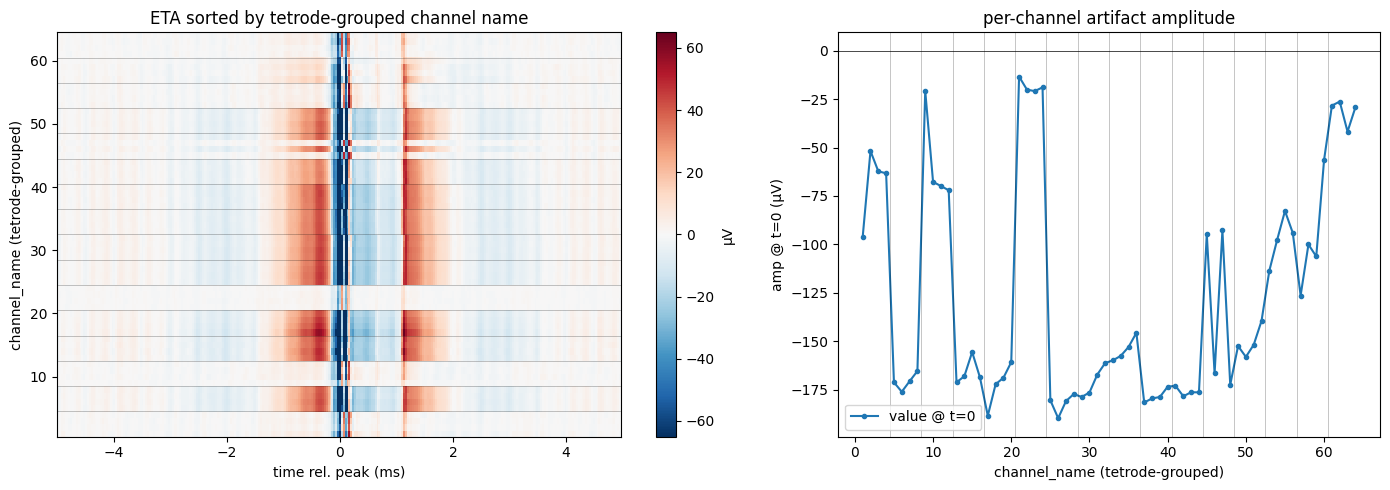

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5),
                          gridspec_kw={"width_ratios": [1.3, 1]})

vmax = np.percentile(np.abs(eta_by_name), 99)
im = axes[0].imshow(eta_by_name.T, aspect="auto", origin="lower",
                    extent=[t_snip[0], t_snip[-1],
                            name_sorted[0] - 0.5, name_sorted[-1] + 0.5],
                    vmin=-vmax, vmax=vmax, cmap="RdBu_r", interpolation="nearest")
# Draw tetrode boundaries every 4 channels.
for tb in range(4, 64, 4):
    axes[0].axhline(tb + 0.5, color="k", lw=0.4, alpha=0.4)
axes[0].set(xlabel="time rel. peak (ms)", ylabel="channel_name (tetrode-grouped)",
            title="ETA sorted by tetrode-grouped channel name")
fig.colorbar(im, ax=axes[0], label="\u00b5V")

axes[1].plot(name_sorted, amp_name, ".-", color="C0", label="value @ t=0")
for tb in range(4, 64, 4):
    axes[1].axvline(tb + 0.5, color="k", lw=0.4, alpha=0.4)
axes[1].set(xlabel="channel_name (tetrode-grouped)", ylabel="amp @ t=0 (\u00b5V)",
            title="per-channel artifact amplitude")
axes[1].axhline(0, color="k", lw=0.5)
axes[1].legend()

fig.tight_layout()
plt.show()

## 6. Apply the same pipeline to recordings 1 and 2

In [23]:
def analyze_recording(rec_idx: int):
    da = load_tetrode_dataarray(
        ACQ_DIR,
        recording_index=rec_idx,
        stream_index=STREAM_INDEX,
        selected_tetrodes=SELECTED_TETRODES,
        layout="2d_flat_index",
    )
    fs_ = float(da.attrs["fs"])
    freqs, psds = channel_psds(da.values, fs=fs_)
    mean_psd = psds.mean(axis=1)
    peak_f, peak_db, _ = find_psd_peaks(freqs, mean_psd, fmin=1.0)
    groups = harmonic_groups(peak_f)
    peaks, hp, thr = detect_transients(da.values[:, 0], fs=fs_)
    diffs = np.diff(peaks)
    vals, counts = np.unique(diffs, return_counts=True)
    modal = int(vals[counts.argmax()]) if vals.size else 0
    exact = int(np.sum(diffs == modal)) if vals.size else 0
    return {
        "rec_idx": rec_idx,
        "da": da,
        "fs": fs_,
        "duration_s": da.sizes["time"] / fs_,
        "freqs": freqs,
        "mean_psd": mean_psd,
        "peak_f": peak_f,
        "peak_db": peak_db,
        "harmonic_groups": groups,
        "events": peaks,
        "diffs": diffs,
        "modal_interval": modal,
        "modal_freq": fs_ / modal if modal else float("nan"),
        "exact_frac": exact / diffs.size if diffs.size else float("nan"),
        "event_rate": len(peaks) / (da.sizes["time"] / fs_),
    }


results = [analyze_recording(i) for i in (0, 1, 2)]

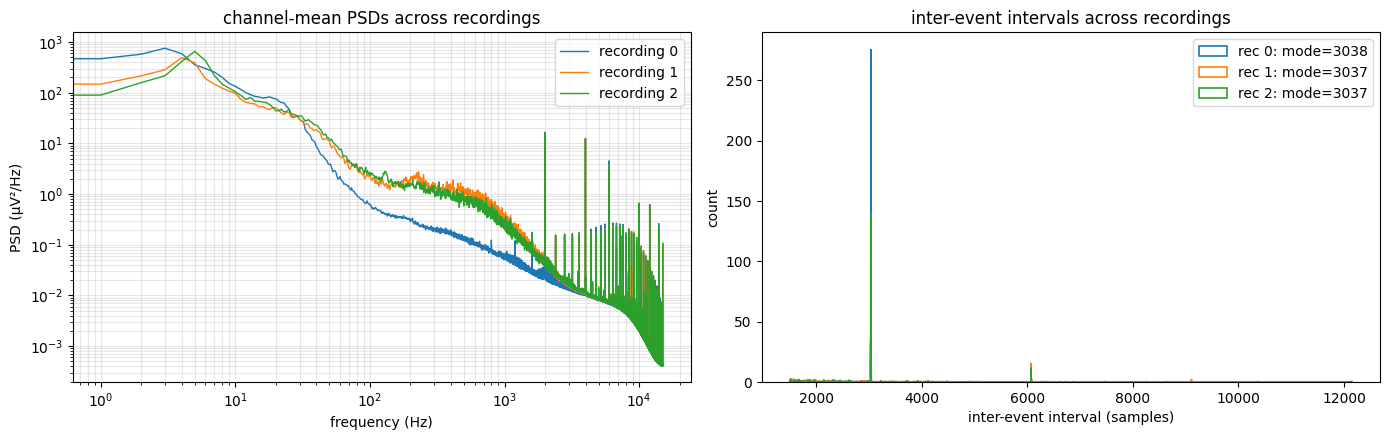

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for r, color in zip(results, ["C0", "C1", "C2"]):
    axes[0].loglog(r["freqs"], r["mean_psd"], color=color, lw=1,
                   label=f"recording {r['rec_idx']}")
axes[0].set(xlabel="frequency (Hz)", ylabel="PSD (\u00b5V\u00b2/Hz)",
            title="channel-mean PSDs across recordings")
axes[0].legend()
axes[0].grid(True, which="both", alpha=0.3)

for r, color in zip(results, ["C0", "C1", "C2"]):
    if r["diffs"].size:
        axes[1].hist(r["diffs"], bins=np.arange(r["diffs"].min() - 0.5,
                                                  r["diffs"].max() + 1.5),
                     histtype="step", color=color, lw=1.2,
                     label=f"rec {r['rec_idx']}: mode={r['modal_interval']}")
axes[1].set(xlabel="inter-event interval (samples)", ylabel="count",
            title="inter-event intervals across recordings")
axes[1].legend()

fig.tight_layout()
plt.show()

In [25]:
print(f"{'rec':>4} {'dur (s)':>9} {'n_events':>9} {'rate (Hz)':>10} "
      f"{'modal (samp)':>13} {'modal (Hz)':>11} {'%exact':>7}")
for r in results:
    print(f"{r['rec_idx']:>4} {r['duration_s']:>9.3f} {len(r['events']):>9d} "
          f"{r['event_rate']:>10.4f} {r['modal_interval']:>13d} "
          f"{r['modal_freq']:>11.4f} {r['exact_frac'] * 100:>6.1f}")

print("\nHarmonic groups per recording (fundamental \u2192 [orders present]):")
for r in results:
    print(f"  rec {r['rec_idx']}:")
    for f0 in sorted(r["harmonic_groups"]):
        series = r["harmonic_groups"][f0]
        if len(series) == 1:
            print(f"    isolated {f0:7.2f} Hz")
        else:
            orders = ", ".join(str(o) for o, _ in series)
            print(f"    f0 = {f0:7.2f} Hz, orders: {orders}")

 rec   dur (s)  n_events  rate (Hz)  modal (samp)  modal (Hz)  %exact
   0    60.503       598     9.8838          3038      9.8749   46.2
   1    60.249       600     9.9587          3037      9.8782   19.5
   2    59.631       577     9.6762          3037      9.8782   24.3

Harmonic groups per recording (fundamental → [orders present]):
  rec 0:
    f0 = 1596.00 Hz, orders: 1, 2, 3, 4, 5, 5, 5, 6, 6, 6, 6, 7, 7, 7, 7, 7, 8, 8, 8, 9, 9, 9, 9, 9, 9, 9
    f0 = 1995.00 Hz, orders: 1, 2, 3, 5, 6, 6, 6, 7, 7
    f0 = 2394.00 Hz, orders: 1, 3, 3
    f0 = 2793.00 Hz, orders: 1, 2, 3, 3
    isolated 3592.00 Hz
    isolated 4390.00 Hz
    isolated 5188.00 Hz
    isolated 6784.00 Hz
  rec 1:
    f0 = 1995.00 Hz, orders: 1, 2, 3, 4, 4, 4, 5, 5, 5, 5, 6, 6, 6, 6, 6, 6, 7, 7, 7, 7, 7, 7, 7
    f0 = 2394.00 Hz, orders: 1, 2, 3, 3, 4, 6, 6
    f0 = 2793.00 Hz, orders: 1, 2, 3, 3, 4, 4, 4
    f0 = 3192.00 Hz, orders: 1, 2, 4, 4
    isolated 3591.00 Hz
    isolated 4389.00 Hz
    isolated 5188.00 Hz

## Summary

### Spectral peaks (mean PSD)

The greedy `harmonic_groups` helper splits a single harmonic series across
several "fundamentals" because it locks onto the first peak it sees. In
recording 0 the helper reports fundamentals at 1596, 1995, 2394, 2793 Hz
and isolated peaks at 3592, 4390, 5188, 6784 Hz. **All of these differ
by ~399 Hz** (1995 − 1596 = 399, 2394 − 1995 = 399, …), so the true
underlying fundamental is ~399–400 Hz. At our 1 Hz PSD resolution this is
indistinguishable from `fs / 75 = 400` Hz, i.e. a 75-sample periodic
component leaking into the acquired signal.

There is no clean 60 Hz / mains family above the prominence threshold —
mains contamination is at most modest on this rig.

### Per-channel peak agreement (section 2b)

When the same peak detector is run on each channel's PSD individually,
**37 candidate peaks are present on all 24 channels** (within ±1 Hz),
including the full ~399 Hz harmonic ladder (1995, 3192, 3592, 3991,
4390, 4789, 5188, 5587, …) plus high-frequency peaks at 8052, 10047,
14038, 14366, 14437, 14765, 14836 Hz. 2793 Hz hits 23/24 channels. The
near-perfect cross-channel agreement is a strong signature of
common-mode interference from a clocked source upstream of the per-
channel signal path. (1596 Hz is *not* universal, which suggests it
sits below the per-channel detection threshold on some channels rather
than being a separate phenomenon.)

### ~10 Hz transient — combined vs sign-aware detection (section 4b)

| detector            | n_events | modal interval | modal rate | %exact | ±1 sample |
|---------------------|---------:|---------------:|-----------:|-------:|----------:|
| combined `|hp|`     | 598      | 3038 samp      | 9.8749 Hz  | 46.2 % | 62.3 %    |
| positive only       | 367      | 3038 samp      | 9.8749 Hz  | 44.5 % | 59.8 %    |
| **negative only**   | **598**  | **3038 samp**  | **9.8749 Hz** | **53.4 %** | **71.7 %** |

- The artifact is **predominantly a negative transient**: the
  negative-only detector finds the same 598 events as the combined
  detector, while the positive detector finds only 367 (and 36 of its
  intervals fall at ~6075 samples = `2 × period`, meaning it missed
  every other event).
- Restricting to negative peaks tightens the modal-interval fraction
  from 46 % → **53 %** exact and 62 % → **72 %** within ±1 sample, so
  the combined detector had indeed been mixing positive and negative
  lobes and inflating jitter — exactly as suspected.
- Even after sign-locking, the distribution is **not perfectly sample-
  precise**: residual jitter is symmetric and small (±5 samples). The
  true period most likely sits just under 3038 samples, with rounding
  causing the occasional 3037-sample interval.

### ~10 Hz transient across recordings

Same modal interval (3037–3038 samples ≈ 9.87 Hz) across all three
recordings → hardware-clocked. The exact-match fraction is much higher
for recording 0 (46 %) than recordings 1 and 2 (~20 %), but those were
measured with the combined detector and would tighten with the
sign-aware detector.

### Spatial pattern: OE index vs tetrode-grouped channel name (section 5b)

Spatial-FFT of artifact amplitude at `t = 0`:

| ordering                       | top spatial frequency | period (channels) |
|--------------------------------|-----------------------|-------------------|
| OE index 0..63                 | **k = 32** (dominant) | **2.00**          |
| OE index 0..63                 | k = 31                | 2.06              |
| OE index 0..63                 | k = 3                 | 21.3              |
| channel_name (tetrode order)   | k = 1                 | 64                |
| channel_name (tetrode order)   | k = 6                 | 10.7              |
| channel_name (tetrode order)   | k = 5                 | 12.8              |

The **period-2 alternation in OE-index space disappears when channels
are re-ordered by tetrode-grouped name**: the dominant spatial component
drops from period 2 to period 64 (a smooth gradient) plus broad mid-
frequency content with no obvious 4-wide tetrode block structure. That
is the smoking gun for a **multiplexer / ADC-bound artifact**: the
period-2 pattern only exists in the order in which channels are sampled
by the acquisition board, not in the order in which electrodes are
physically grouped into tetrodes. The artifact is internal to the
headstage / acquisition board, not the tissue or the tetrode geometry.
